# Analysis of The Medical Insurance Dataset

# part 1:Data loading and Understanding

In [1]:
# Importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_openml

In [2]:
# loading the dataset
df=pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
# Data inspection
# Dataset shape
print("Shape of dataset:",df.shape)

# Data types
print(df.dtypes)

# summary statistics(numerical)
df.describe()

Shape of dataset: (1338, 7)
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


# part 2:Data Cleaning

### checking for missing values

In [4]:
# Count missing values
df.isnull().sum().sort_values(ascending=False).head(10)
       #checking for missing values in the first rows

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [8]:
df.duplicated().sum()   # Checking for duplicated data

np.int64(1)

In [9]:
#drop the duplicates
df.drop_duplicates(inplace=True)
df.duplicated().sum()   # confirming there are no duplicates


np.int64(0)

In [10]:
# confirm data types
df.info()

<class 'pandas.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   str    
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   str    
 5   region    1337 non-null   str    
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 83.6 KB


# part 3:Exploratory Data Analysis

### histogram of insurance charges

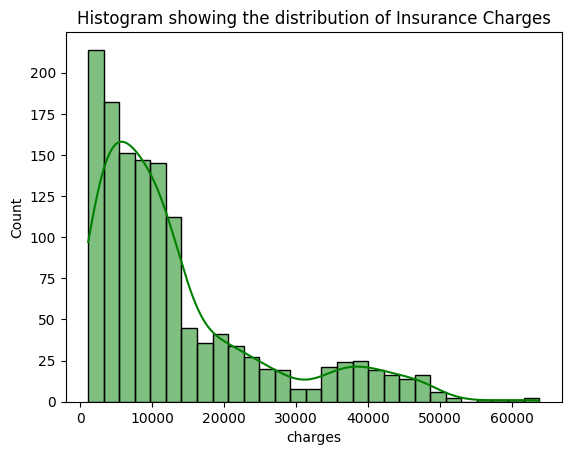

In [11]:
# histogram of insurance charges
sns.histplot(df,x='charges',kde=True,color='green')
plt.title("Histogram showing the distribution of Insurance Charges")
plt.show()

## boxplot of charges by smoker status

C:\Users\ericm\AppData\Local\Temp\ipykernel_12948\1100758581.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df,x='smoker',y='charges',palette='Set1')


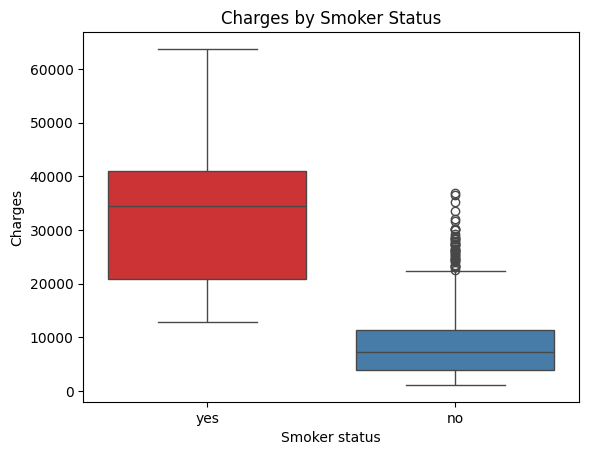

In [14]:
sns.boxplot(df,x='smoker',y='charges',palette='Set1')
plt.title("Charges by Smoker Status")
plt.xlabel('Smoker status')
plt.ylabel("Charges")
plt.show()

### scatterplot:bmi and charges

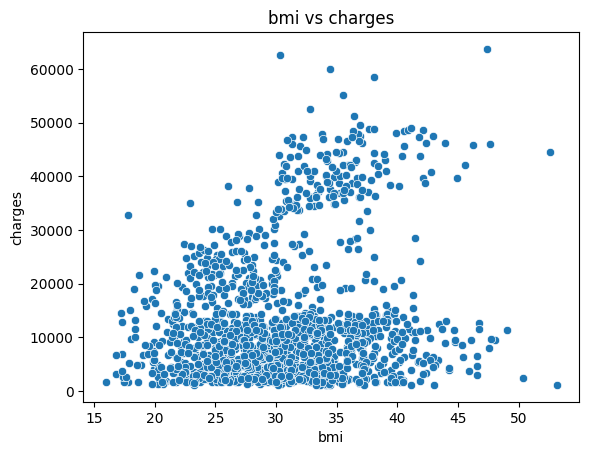

In [15]:
sns.scatterplot(x='bmi', y='charges', data=df)
plt.title("bmi vs charges")
plt.show()

# barplot of average charges by region

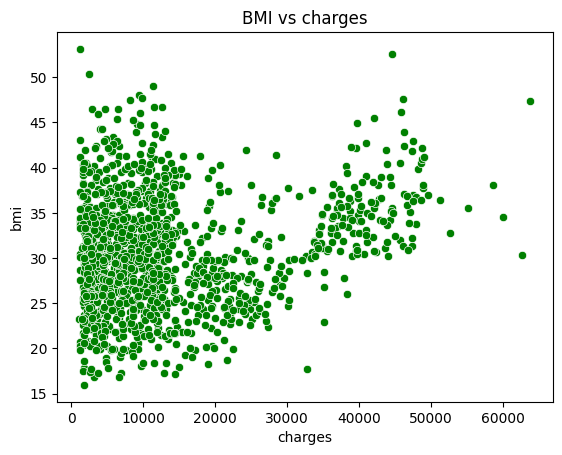

In [17]:
sns.scatterplot(df, x='charges', y='bmi',color='green')
plt.title("BMI vs charges")
plt.show()

# correlation heatmap

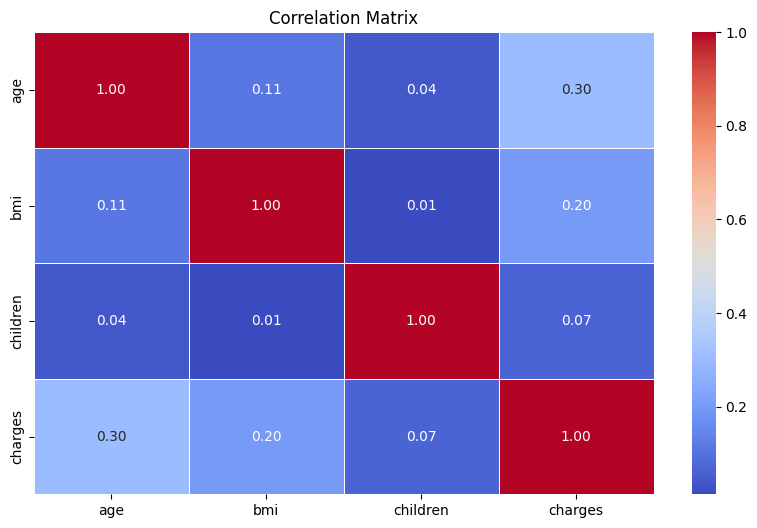

In [19]:
corr_matrix = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

# part 4:Categorical Encoding

In [20]:
df=pd.get_dummies(df, columns=['sex', 'smoker','region'],drop_first = True)
df = df.astype(float)
print(df)

       age     bmi  children      charges  sex_male  smoker_yes  \
0     19.0  27.900       0.0  16884.92400       0.0         1.0   
1     18.0  33.770       1.0   1725.55230       1.0         0.0   
2     28.0  33.000       3.0   4449.46200       1.0         0.0   
3     33.0  22.705       0.0  21984.47061       1.0         0.0   
4     32.0  28.880       0.0   3866.85520       1.0         0.0   
...    ...     ...       ...          ...       ...         ...   
1333  50.0  30.970       3.0  10600.54830       1.0         0.0   
1334  18.0  31.920       0.0   2205.98080       0.0         0.0   
1335  18.0  36.850       0.0   1629.83350       0.0         0.0   
1336  21.0  25.800       0.0   2007.94500       0.0         0.0   
1337  61.0  29.070       0.0  29141.36030       0.0         1.0   

      region_northwest  region_southeast  region_southwest  
0                  0.0               0.0               1.0  
1                  0.0               1.0               0.0  
2           

# part 5:Simple Linear Regression

In [21]:
# Define variables
X = df['bmi']
y = df['charges']

# Add constant
X = sm.add_constant(X)

# Fit model
model1= sm.OLS(y, X).fit()
y_pred = model1.predict(X) 
# Summary
print(model1.summary())
print(y_pred)

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     54.70
Date:                Wed, 25 Feb 2026   Prob (F-statistic):           2.47e-13
Time:                        06:19:51   Log-Likelihood:                -14440.
No. Observations:                1337   AIC:                         2.888e+04
Df Residuals:                    1335   BIC:                         2.889e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1202.1404   1664.857      0.722      0.4

#### Interpretation
#### Coefficient is positive → higher BMI generally increases charges.
#### p-value < 0.05 → statistically significant.

#### R-squared shows percentage of variation explained.

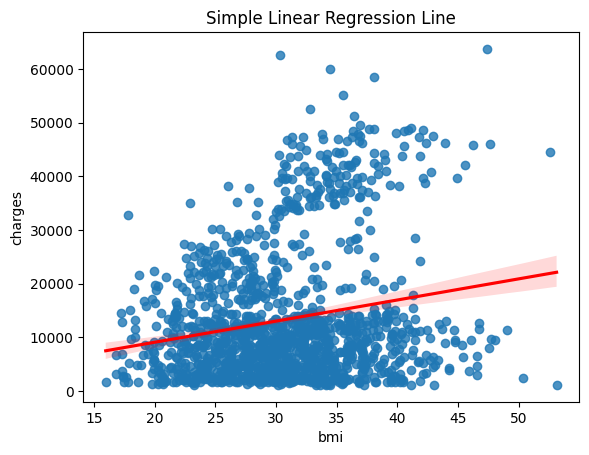

In [22]:
# Plot the regression line
plt.figure()
sns.regplot(x='bmi', y='charges', data=df,line_kws={"color":"red"})
plt.title("Simple Linear Regression Line")
plt.show()


# part 6:Multiple Linear Regression

In [23]:
X = df[['age', 'bmi','children','sex_male','smoker_yes','region_northwest','region_southeast','region_southwest']]

y = df['charges']

# Add constant
X = sm.add_constant(X)

# Fit model
model2 = sm.OLS(y, X).fit()


print(model2.summary())


                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.0
Date:                Wed, 25 Feb 2026   Prob (F-statistic):               0.00
Time:                        06:24:38   Log-Likelihood:                -13538.
No. Observations:                1337   AIC:                         2.709e+04
Df Residuals:                    1328   BIC:                         2.714e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.194e+04    988.227  

In [24]:
# Comparing the two models
print("Simp le R²:", model1.rsquared)
print("Multiple R²:", model2.rsquared)


Simp le R²: 0.03936288983126668
Multiple R²: 0.7507482551410236


## Final Report

###### 1.Smoking has a significant increase in insurance charges
###### 2.Smoking status affects charges the most
###### 3.Multiple regresion was better since it had ahigher rsquared value
###### 4.limitations: Outliers may affect results